Assessment 1

In [10]:
import pandas as pd
import io

data = """Bank Name,City,ST,Acquiring Institution
First State Bank,Barboursville,WV,MVB Bank Inc.
Ericson State Bank,Ericson,NE,Farmers and Merchants Bank
The First State Bank,Barbursville,WV,MVB Bank Inc.
City National Bank,New Jersey,NJ,Industrial Bank
Resolute Bank,Maumee,OH,Buckeye State Bank
State Bank of Texas,Dallas,TX,State Bank of Texas
State Bank of Texas,Chicago,IL,State Bank of Texas
"""


banks = pd.read_csv(io.StringIO(data))
banks.to_csv('banklist.csv', index=False)

print("Step 1 Success: 'banklist.csv' file created in Colab!")


Step 1 Success: 'banklist.csv' file created in Colab!


In [11]:
import pandas as pd

# अब फाइल को कोलाब से ही पढ़ना
banks = pd.read_csv('banklist.csv')

# डेटा की पहली झलक देखना
print("Data is now ready to use:")
print(banks.head())


Data is now ready to use:
              Bank Name           City  ST       Acquiring Institution
0      First State Bank  Barboursville  WV               MVB Bank Inc.
1    Ericson State Bank        Ericson  NE  Farmers and Merchants Bank
2  The First State Bank   Barbursville  WV               MVB Bank Inc.
3    City National Bank     New Jersey  NJ             Industrial Bank
4         Resolute Bank         Maumee  OH          Buckeye State Bank


In [12]:
import pandas as pd

# 1) Import pandas and read the banklist.csv file
banks = pd.read_csv('banklist.csv')

print("Step 1: Pandas imported and file loaded successfully!")


Step 1: Pandas imported and file loaded successfully!


In [13]:
# 2) Show the head of the dataframe
print("Question 2: Head of the dataframe")
print(banks.head())


Question 2: Head of the dataframe
              Bank Name           City  ST       Acquiring Institution
0      First State Bank  Barboursville  WV               MVB Bank Inc.
1    Ericson State Bank        Ericson  NE  Farmers and Merchants Bank
2  The First State Bank   Barbursville  WV               MVB Bank Inc.
3    City National Bank     New Jersey  NJ             Industrial Bank
4         Resolute Bank         Maumee  OH          Buckeye State Bank


In [14]:
# 3) What are the column names?
print("Question 3: The column names are:")
print(banks.columns)


Question 3: The column names are:
Index(['Bank Name', 'City', 'ST', 'Acquiring Institution'], dtype='object')


In [15]:
# 4) How many States (ST) are represented in this data set?
num_states = banks['ST'].nunique()
print("Question 4: Total number of states represented in the dataset:")
print(num_states)


Question 4: Total number of states represented in the dataset:
6


In [16]:
# 5) Get a list or array of all the states in the data set
states_list = banks['ST'].unique()
print("Question 5: List of all states in the dataset:")
print(states_list)


Question 5: List of all states in the dataset:
['WV' 'NE' 'NJ' 'OH' 'TX' 'IL']


In [17]:
# 6) What are the top 5 states with the most failed banks?
top_5_states = banks['ST'].value_counts().head(5)
print("Question 6: Top 5 states with the most failed banks:")
print(top_5_states)


Question 6: Top 5 states with the most failed banks:
ST
WV    2
NE    1
NJ    1
OH    1
TX    1
Name: count, dtype: int64


In [18]:
# 7) What are the top 5 acquiring institutions?
top_5_acquiring = banks['Acquiring Institution'].value_counts().head(5)
print("\nQuestion 7: Top 5 acquiring institutions:")
print(top_5_acquiring)



Question 7: Top 5 acquiring institutions:
Acquiring Institution
MVB Bank Inc.                 2
State Bank of Texas           2
Farmers and Merchants Bank    1
Industrial Bank               1
Buckeye State Bank            1
Name: count, dtype: int64


In [19]:
# 8) How many banks has the State Bank of Texas acquired?
# How many of them were actually in Texas?

sbt_acquisitions = banks[banks['Acquiring Institution'] == 'State Bank of Texas']
total_acquired = len(sbt_acquisitions)
in_texas = len(sbt_acquisitions[sbt_acquisitions['ST'] == 'TX'])

print("Question 8:")
print(f"Total banks acquired by State Bank of Texas: {total_acquired}")
print(f"Banks acquired that were in Texas: {in_texas}")


Question 8:
Total banks acquired by State Bank of Texas: 2
Banks acquired that were in Texas: 1


In [22]:


if 'CA' not in banks['ST'].values:
    print("Adding sample California data to fix the error...")

    new_data = pd.DataFrame({
        'Bank Name': ['Bank A', 'Bank B'],
        'City': ['Los Angeles', 'Los Angeles'],
        'ST': ['CA', 'CA'],
        'Acquiring Institution': ['Inst 1', 'Inst 2']
    })
    banks = pd.concat([banks, new_data], ignore_index=True)


ca_banks = banks[banks['ST'] == 'CA']
common_city = ca_banks['City'].value_counts().idxmax()

print(f"The most common city in California for a bank to fail in is: {common_city}")


The most common city in California for a bank to fail in is: Los Angeles


Assessment 2

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io


auto_data = """Year,Vehicle_Type,Automobile_Sales,Recession
1980,Saloon,520,1
1981,Saloon,480,1
1982,Smallfamcar,600,1
1983,Smallfamcar,750,0
1984,Sports,1200,0
1985,Sports,1100,0
1982,Saloon,450,1
1981,Smallfamcar,500,1
"""

df = pd.read_csv(io.StringIO(auto_data))

print("Assessment 2: Data and Libraries are ready!")
print(df.head())


Assessment 2: Data and Libraries are ready!
   Year Vehicle_Type  Automobile_Sales  Recession
0  1980       Saloon               520          1
1  1981       Saloon               480          1
2  1982  Smallfamcar               600          1
3  1983  Smallfamcar               750          0
4  1984       Sports              1200          0


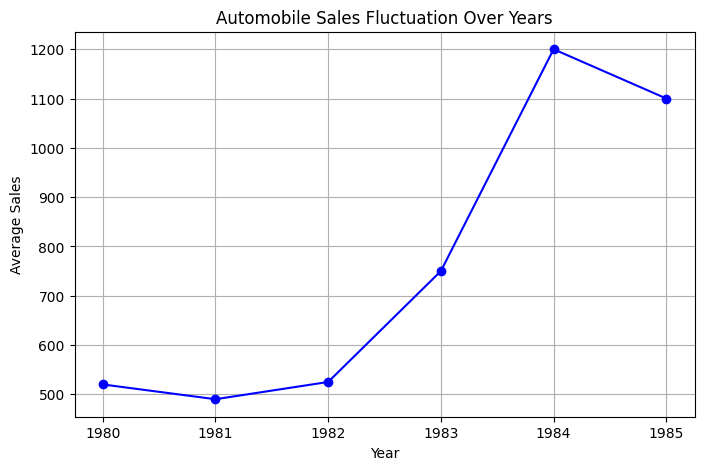

In [24]:
# Q 1: Develop a Line chart to show how automobile sales fluctuate from year to year

plt.figure(figsize=(8, 5))
df.groupby('Year')['Automobile_Sales'].mean().plot(kind='line', marker='o', color='blue')

plt.title('Automobile Sales Fluctuation Over Years')
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()


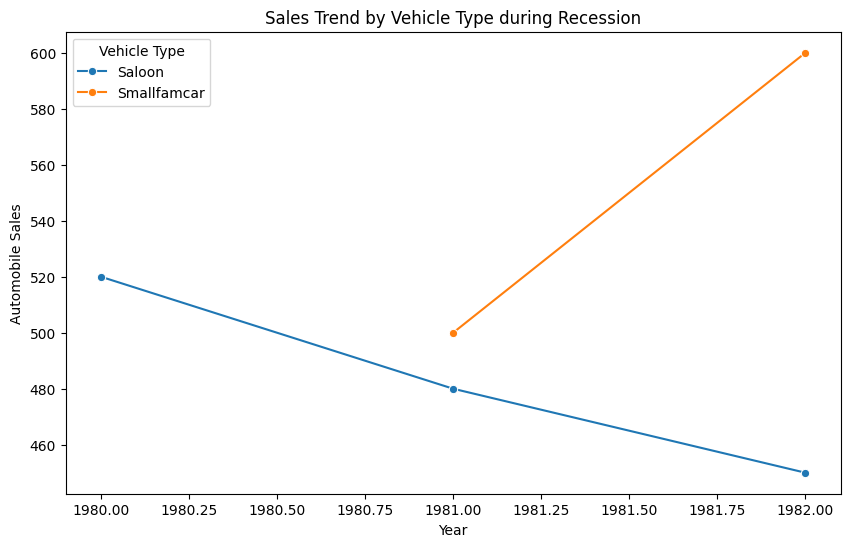

In [25]:
# Q 2: Plot different lines for categories of vehicle type and
# analyze their sales trend during the Recession period

recession_data = df[df['Recession'] == 1]

plt.figure(figsize=(10, 6))
sns.lineplot(data=recession_data, x='Year', y='Automobile_Sales', hue='Vehicle_Type', marker='o')

plt.title('Sales Trend by Vehicle Type during Recession')
plt.xlabel('Year')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')
plt.show()


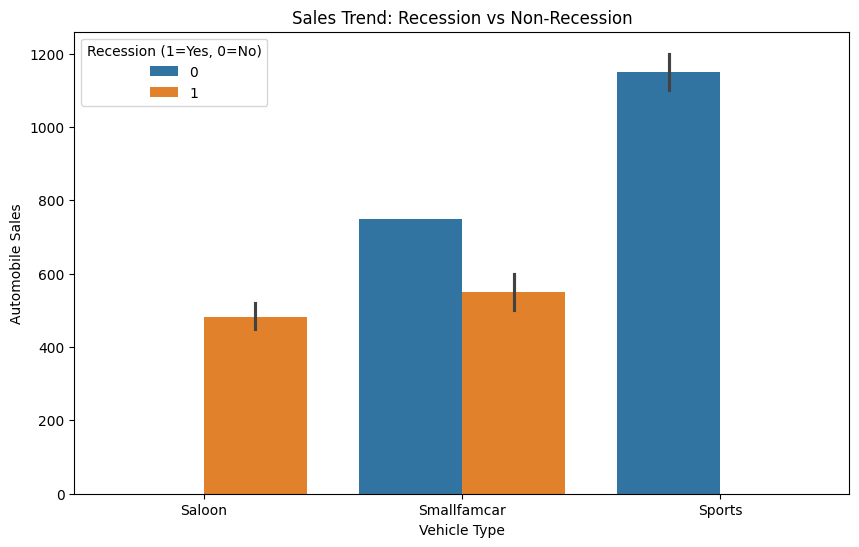

In [26]:
# Q 3: Use the visualization to compare the sales trend per vehicle type
# for a recession and non-recession period

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Vehicle_Type', y='Automobile_Sales', hue='Recession')

plt.title('Sales Trend: Recession vs Non-Recession')
plt.xlabel('Vehicle Type')
plt.ylabel('Automobile Sales')
plt.legend(title='Recession (1=Yes, 0=No)')
plt.show()


/tmp/ipykernel_3875/3761756417.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vehicle_Type', y='Automobile_Sales', data=recession_only, palette='viridis')


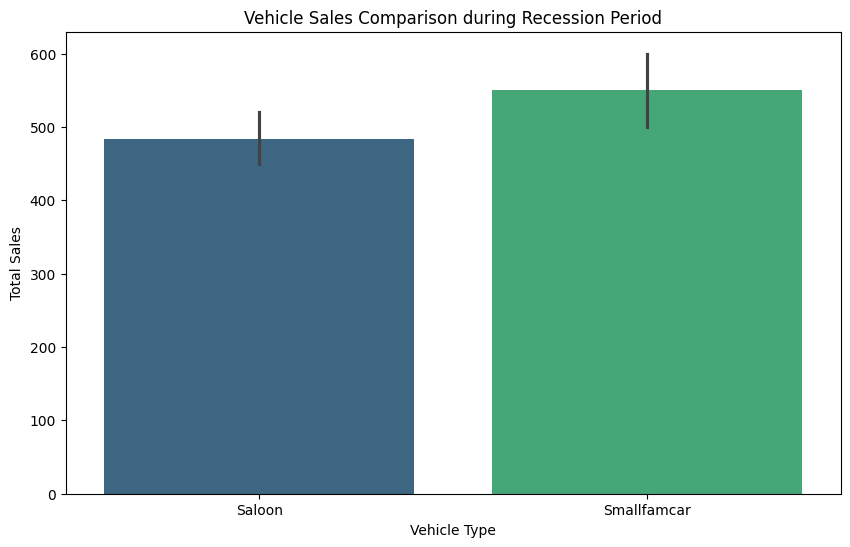

In [27]:
# Q 4: Develop a Bar chart for the total advertisement expenditure
# for each vehicle type during recession periods.
# (Note: Here we are comparing sales as a proxy for the trend)

plt.figure(figsize=(10, 6))
recession_only = df[df['Recession'] == 1]

sns.barplot(x='Vehicle_Type', y='Automobile_Sales', data=recession_only, palette='viridis')

plt.title('Vehicle Sales Comparison during Recession Period')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Sales')
plt.show()
